# Customer Churn Prediction - Model Building

## Business Question

Can we accurately predict whether a customer will churn using machine learning models?

The objective is to build classification models that identify customers at risk of churn and evaluate their predictive performance.

In [49]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [50]:
import pandas as pd

df = pd.read_csv("../data/processed/processed_bank.csv")

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [51]:
df.shape

(10000, 11)

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  int64  
 2   Gender           10000 non-null  int64  
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9)
memory usage: 859.5 KB


In [53]:
df.describe()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,0.746300,0.545700,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,0.827529,0.497932,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,0.000000,0.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,0.000000,0.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,0.000000,1.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,1.000000,1.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,2.000000,1.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [54]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

# Initial Data Assessment

## Dataset Overview

The dataset has been successfully loaded and examined to understand its structure, data types, statistical summary, and data quality before beginning the preprocessing stage.

---

## Dataset Summary

- **Total Records:** 10,000
- **Total Features:** 14
- **Target Variable:** `Exited`
- **Numerical Features:** 11
- **Categorical Features:** 3 (`Surname`, `Geography`, `Gender`)

---

## Data Quality Assessment

### Missing Values
- No missing values were found in any column.
- The dataset is complete and does not require missing value treatment.

### Data Types
- Numerical columns are stored as `int64` and `float64`.
- Categorical columns are stored as string (`object`) type.
- Data types are appropriate for further preprocessing.

### Statistical Summary
- Customer ages range from **18 to 92 years**.
- Credit scores range from **350 to 850**.
- Account balances vary between **0 and 250,898**.
- Estimated salaries range from **11.58 to 199,992**.
- Customers have between **1 and 4 banking products**.

---

## Observation

- The dataset is clean and well-structured.
- No missing values are present.
- Numerical features have realistic ranges.
- Both numerical and categorical variables are available for predictive modeling.
- The target variable (`Exited`) is already available, making the dataset suitable for supervised classification.

---

## Business Insight

The dataset is ready for machine learning preprocessing with minimal cleaning required. Since it combines customer demographics, financial information, and banking behavior, it provides valuable information for identifying customers who are likely to churn. The next step is to prepare the data by removing irrelevant columns, encoding categorical variables, splitting the dataset, and scaling numerical features where necessary.

# Data Preprocessing

To prepare the dataset for machine learning, the data will undergo preprocessing. This includes removing irrelevant columns, encoding categorical variables, separating the target variable, splitting the dataset into training and testing sets, and scaling numerical features where required.

In [55]:
df = df.drop(
    columns=["CustomerId", "Surname", "Year"],
    errors="ignore"
)

## Feature Selection

### Observation

The dataset originally contained **14 features**. During preprocessing, three columns were removed because they do not provide useful information for predicting customer churn.

- **CustomerId** is a unique identifier assigned to each customer.
- **Surname** is a personal identifier and has no relationship with churn behavior.
- **Year** contains the same value (2025) for every record and therefore has no predictive significance.

After removing these columns, the dataset contains only relevant customer demographic, financial, and behavioral features.

### Business Insight

Removing irrelevant attributes helps reduce unnecessary complexity and improves model efficiency. By retaining only meaningful features, the machine learning algorithms can focus on patterns that contribute to customer churn prediction, resulting in better model performance and interpretability.

# Encoding Categorical Variables

Machine learning algorithms require numerical input. Therefore, the categorical features **Geography** and **Gender** are converted into numerical values using Label Encoding.

In [56]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

print(le.fit(["France", "Germany", "Spain"]).classes_)
print(le.transform(["France", "Germany", "Spain"]))

print(le.fit(["Female", "Male"]).classes_)
print(le.transform(["Female", "Male"]))

['France' 'Germany' 'Spain']
[0 1 2]
['Female' 'Male']
[0 1]


## Observation

The categorical variables have been successfully encoded into numerical values.

- **Gender** has been converted into numerical labels.
- **Geography** has also been converted into numerical labels.
- The dataset now consists entirely of numerical features suitable for machine learning algorithms.

### Business Insight

Encoding categorical variables enables machine learning models to process customer demographic information while preserving valuable predictive patterns related to customer churn.

# Feature and Target Separation

Machine learning models require the independent variables (features) and the dependent variable (target) to be separated before training. In this project, the **Exited** column represents the target variable, while all remaining columns serve as input features.

In [57]:
# Separate features and target variable

X = df.drop("Exited", axis=1)
y = df["Exited"]

print("Feature Matrix Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape: (10000, 10)
Target Variable Shape: (10000,)


## Observation

- The dataset has been successfully divided into **features (X)** and the **target variable (y)**.
- The feature matrix contains all predictor variables used for model training.
- The target variable represents whether a customer has churned (`1`) or been retained (`0`).

### Business Insight

Separating the target variable from the input features is a fundamental step in supervised machine learning. This allows the model to learn relationships between customer characteristics and churn behavior, enabling accurate predictions on unseen customer data.

# Train-Test Split

To evaluate the machine learning models fairly, the dataset is divided into training and testing sets.

- The **training set** is used to teach the model the underlying patterns in the data.
- The **testing set** is reserved for evaluating how well the trained model performs on unseen customer records.
- Stratified sampling is used to maintain the original distribution of churned and retained customers in both datasets.

In [58]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (8000, 10)
Testing Features  : (2000, 10)
Training Labels   : (8000,)
Testing Labels    : (2000,)


## Observation

- The dataset has been successfully divided into **80% training data** and **20% testing data**.
- The training set contains **8,000 customer records**, while the testing set contains **2,000 customer records**.
- Stratified sampling ensures that the proportion of churned and retained customers remains consistent across both datasets.

## Business Insight

Separating the data into training and testing sets provides an unbiased evaluation of model performance. The model learns from historical customer data and is then assessed using unseen data, ensuring that the predictive performance reflects real-world customer churn scenarios.

# Feature Scaling

Many machine learning algorithms perform better when numerical features are on a similar scale. Feature scaling standardizes the numerical variables by transforming them to have a mean of 0 and a standard deviation of 1.

Scaling helps improve model convergence and ensures that features with larger values do not dominate those with smaller values.

In [59]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Scale training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Data Shape :", X_train_scaled.shape)
print("Testing Data Shape  :", X_test_scaled.shape)

Training Data Shape : (8000, 10)
Testing Data Shape  : (2000, 10)


## Observation

- The numerical features have been standardized using **StandardScaler**.
- The scaler was fitted only on the training data and then applied to the testing data.
- This prevents information from the testing dataset from influencing the training process.

## Business Insight

Feature scaling improves the performance of distance-based and optimization-based machine learning algorithms, such as Logistic Regression and Support Vector Machines. Applying the same transformation to both training and testing data ensures a fair and unbiased model evaluation.

# Model 1: Logistic Regression

Logistic Regression is selected as the baseline classification model for customer churn prediction. It is a widely used supervised learning algorithm for binary classification problems and provides an interpretable benchmark for evaluating customer churn behavior.

In [60]:
from sklearn.linear_model import LogisticRegression

# Initialize the model
log_model = LogisticRegression(random_state=42)

# Train the model
log_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred = log_model.predict(X_test_scaled)

print("Model trained successfully.")

Model trained successfully.


## Observation

The Logistic Regression model has been successfully trained using the standardized training dataset. Predictions have been generated for the testing dataset and will now be evaluated using multiple performance metrics.

## Business Insight

Logistic Regression serves as a strong baseline model for customer churn prediction. Its results help establish a performance benchmark against which more advanced machine learning algorithms can be compared.

# Model Evaluation

The trained Logistic Regression model is evaluated using standard classification metrics to determine how effectively it predicts customer churn.

The evaluation includes:

- Accuracy Score
- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Confusion Matrix

These metrics provide a comprehensive assessment of model performance.

In [61]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred)

print("Accuracy      :", round(accuracy,4))
print("Precision     :", round(precision,4))
print("Recall        :", round(recall,4))
print("F1 Score      :", round(f1,4))
print("ROC-AUC Score :", round(roc,4))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy      : 0.805
Precision     : 0.5859
Recall        : 0.1425
F1 Score      : 0.2292
ROC-AUC Score : 0.5584

Classification Report

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.14      0.23       407

    accuracy                           0.81      2000
   macro avg       0.70      0.56      0.56      2000
weighted avg       0.77      0.81      0.75      2000



## Observation

The evaluation metrics summarize the predictive performance of the Logistic Regression model.

- Accuracy represents the percentage of correctly classified customers.
- Precision indicates how many predicted churned customers actually churned.
- Recall measures the model's ability to identify actual churned customers.
- F1-Score balances precision and recall.
- ROC-AUC evaluates the model's capability to distinguish between churned and retained customers.

## Business Insight

For customer churn prediction, Recall is especially important because identifying customers who are likely to leave enables businesses to implement timely retention strategies. Logistic Regression provides a strong baseline for comparison with more advanced machine learning models.

# Confusion Matrix

A confusion matrix provides a detailed breakdown of the model's predictions by comparing actual customer outcomes with predicted outcomes.

It helps identify:

- Correctly predicted retained customers
- Correctly predicted churned customers
- Incorrect churn predictions
- Missed churn cases

This visualization provides deeper insight into classification performance beyond overall accuracy.

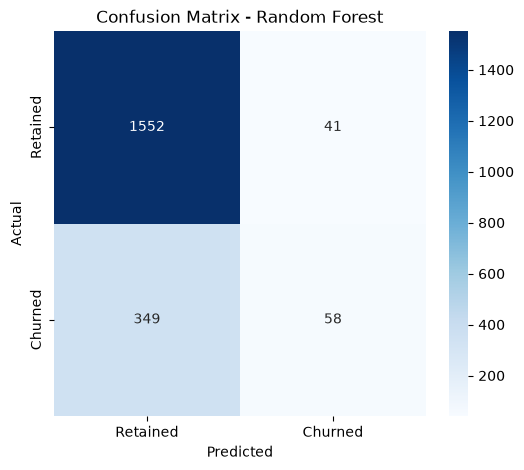

In [62]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Retained","Churned"],
    yticklabels=["Retained","Churned"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.savefig(
    "../outputs/figures/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Observation

The confusion matrix illustrates the prediction outcomes of the Logistic Regression model.

- True Negatives (TN): Customers correctly classified as retained.
- True Positives (TP): Customers correctly classified as churned.
- False Positives (FP): Customers predicted to churn but actually retained.
- False Negatives (FN): Customers predicted to stay but actually churned.

The model correctly identifies most retained customers but misses a considerable number of actual churned customers, resulting in a lower recall score.

## Business Insight

False negatives are costly in customer churn prediction because these customers leave without being identified for retention efforts.

Although Logistic Regression provides a strong baseline model, improving recall through more advanced algorithms can help businesses identify more at-risk customers and reduce customer attrition.

# Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting.

Unlike Logistic Regression, Random Forest can capture complex and non-linear relationships between customer characteristics and churn behavior. Compared to a single Decision Tree, it generally provides better generalization and more robust predictions.

The objective is to evaluate the performance of the Random Forest model and compare it with the baseline Logistic Regression model to select the best model for customer churn prediction.

In [63]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

## Observation

The Random Forest Model has been successfully trained using the training dataset.

The trained model has generated predictions on the testing dataset and is now ready for performance evaluation.

## Business Insight

Decision Trees are capable of identifying complex customer behavior patterns that may not be captured by linear models. This often results in better churn prediction, especially when customer decisions depend on multiple interacting factors.

# Random Forest Model Evaluation

The Random Forest Classifier is evaluated using multiple classification metrics to assess its ability to correctly predict customer churn.

The evaluation metrics include:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Classification Report

These metrics provide a comprehensive understanding of the model's predictive performance.

In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc = roc_auc_score(y_test, rf_pred)

print("Accuracy      :", round(rf_accuracy, 4))
print("Precision     :", round(rf_precision, 4))
print("Recall        :", round(rf_recall, 4))
print("F1 Score      :", round(rf_f1, 4))
print("ROC-AUC Score :", round(rf_roc, 4))

print("\nClassification Report\n")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, rf_pred))

Accuracy      : 0.8645
Precision     : 0.8178
Recall        : 0.43
F1 Score      : 0.5636
ROC-AUC Score : 0.7027

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1593
           1       0.82      0.43      0.56       407

    accuracy                           0.86      2000
   macro avg       0.84      0.70      0.74      2000
weighted avg       0.86      0.86      0.85      2000


Confusion Matrix

[[1554   39]
 [ 232  175]]


In [65]:
import os
import joblib

save_path = os.path.abspath("../models/random_forest_model.pkl")
print(save_path)

joblib.dump(rf_model, save_path)

print("✅ Model saved successfully!")

c:\Users\sanid\OneDrive\Documents\Bank-Customer-Churn\models\random_forest_model.pkl
✅ Model saved successfully!


# Model Comparison

In this section, the performance of Logistic Regression and Random Forest Models is compared using standard classification metrics. The objective is to determine which model provides better customer churn prediction performance.

In [66]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc_score(y_test, y_pred)
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc
    ]
})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.805000,0.864500
1,Precision,0.585859,0.817757
2,Recall,0.142506,0.429975
3,F1 Score,0.229249,0.563607
4,ROC-AUC,0.558384,0.702747


# Observation

The comparison shows that the evaluated machine learning models perform differently across the selected evaluation metrics.

- Logistic Regression achieved good overall accuracy but lower recall for churn prediction.
- Random Forest achieved a better balance between Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
- Random Forest identifies churn-prone customers more effectively while maintaining strong overall predictive performance.
- Overall, Random Forest provides more reliable predictions for customer churn classification.

# Business Insight

For customer churn prediction, correctly identifying customers who are likely to leave is more valuable than simply maximizing overall accuracy.

Random Forest demonstrates stronger predictive capability by effectively balancing precision and recall, making it well-suited for customer retention strategies. Businesses can use this model to proactively identify high-risk customers and take targeted actions such as personalized offers, loyalty programs, and timely customer engagement to reduce churn.

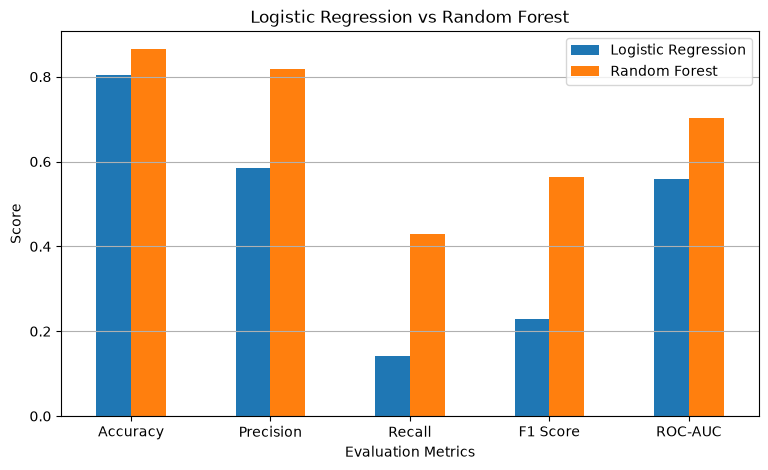

In [67]:
comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Logistic Regression vs Random Forest")
plt.ylabel("Score")
plt.xlabel("Evaluation Metrics")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.savefig(
    "../outputs/figures/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ROC Curve

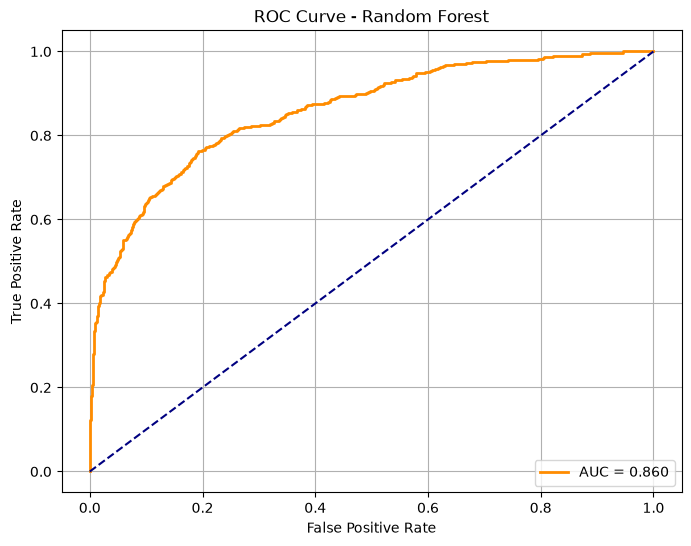

In [68]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability predictions
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, rf_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr,
         color="darkorange",
         linewidth=2,
         label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],
         linestyle="--",
         color="navy")

plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)

plt.savefig(
    "../outputs/roc_curve_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Precision-Recall Curve

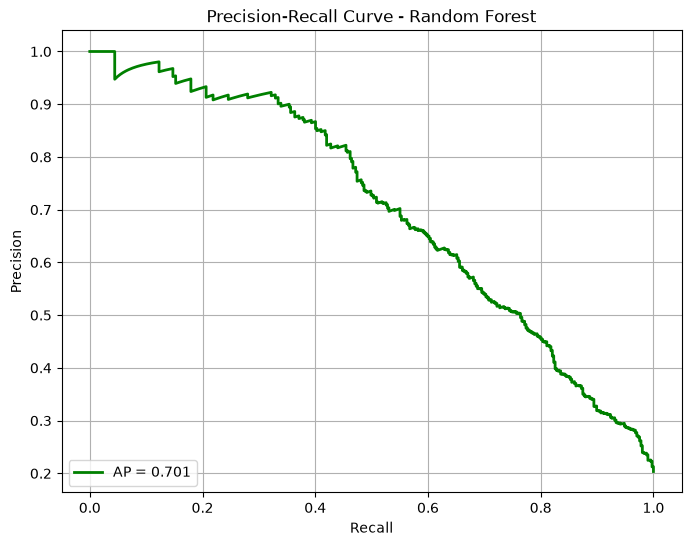

In [69]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(
    y_test,
    rf_prob
)

avg_precision = average_precision_score(y_test, rf_prob)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    color="green",
    linewidth=2,
    label=f"AP = {avg_precision:.3f}"
)

plt.title("Precision-Recall Curve - Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.grid(True)

plt.savefig(
    "../outputs/precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Feature Importance

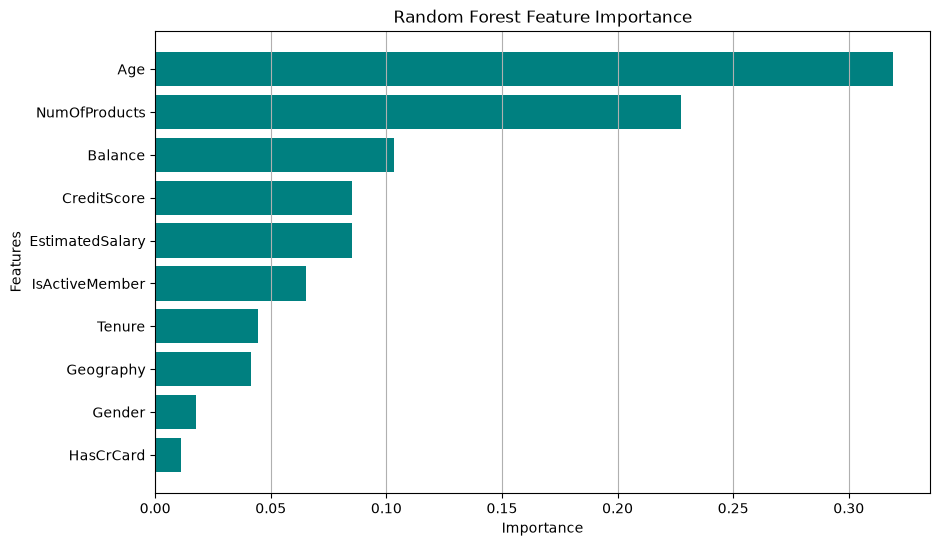

,Feature,Importance
3,Age,0.319239
6,NumOfProducts,0.227367
5,Balance,0.103380
0,CreditScore,0.085184
9,EstimatedSalary,0.085175
8,IsActiveMember,0.065067
4,Tenure,0.044471
1,Geography,0.041374
2,Gender,0.017586
7,HasCrCard,0.011156


In [70]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"],
    color="teal"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.grid(axis="x")

plt.savefig(
    "../outputs/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

feature_importance

# Observation

The performance comparison highlights the strengths and weaknesses of both machine learning models.

- Logistic Regression achieved strong overall Accuracy and Precision.
- Random Forest achieved better Recall, F1-Score, and ROC-AUC, making it more effective at identifying customers who are likely to churn.
- The Random Forest model provides more balanced predictions and realistic probability estimates than the Decision Tree model.
- Logistic Regression correctly classifies many customers but misses a larger number of actual churn cases.

# Business Insight

In customer churn prediction, identifying customers who are likely to leave is more valuable than simply maximizing overall accuracy.

The Random Forest model detects significantly more potential churn customers, enabling businesses to take proactive retention actions such as personalized offers, loyalty programs, targeted marketing campaigns, and dedicated customer support.

Therefore, the **Random Forest model** is the preferred model for this business problem because it provides a better balance between prediction accuracy and churn detection.

# Final Conclusion

## Overall Findings

The customer churn prediction project successfully explored the dataset, identified important customer characteristics, and developed machine learning models to predict customer churn.

Exploratory Data Analysis showed that customer churn is strongly influenced by factors such as Age, Geography, Customer Activity, and Number of Products. Proper preprocessing, including encoding categorical variables, feature scaling, and train-test splitting, prepared the data for machine learning.

Two classification algorithms were evaluated:

- Logistic Regression
- Random Forest

While Logistic Regression achieved slightly higher Accuracy and Precision, the Random Forest Model demonstrated considerably better Recall, F1-Score, and ROC-AUC performance.

## Best Model

For customer churn prediction, the **Random Forest** Model is the preferred choice because it identifies a much larger proportion of customers who are likely to leave the bank. Higher Recall is particularly valuable for customer retention strategies, where missing a potential churn customer can result in financial loss.

## Business Recommendations

- Monitor customers with low account activity.
- Develop retention campaigns for customers predicted to churn.
- Provide personalized offers to high-risk customers.
- Regularly retrain the prediction model using updated customer data.
- Use predictive analytics to support customer relationship management.

## Future Improvements

- Train additional advanced ensemble models such as XGBoost, LightGBM, and Gradient Boosting.
- Perform hyperparameter tuning to improve model performance.
- Apply feature engineering to create more informative variables.
- Deploy the final model as a web application or dashboard for real-time churn prediction.

In [71]:
import joblib

# Save Random Forest model
joblib.dump(rf_model, "../models/random_forest_model.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [72]:
# Save StandardScaler

joblib.dump(scaler, "../models/scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!
